# packs

In [51]:
import transformers
from transformers import AutoModel, AutoTokenizer
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import random
import numpy as np

In [52]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, classification_report

# functions

## read data functions

In [31]:
def read_json(json_path):
  with open(json_path, 'r') as f:
    data = json.load(f)
    return data

In [32]:
def read_jsonl_file(nl_file_path, return_df=True):
    """
    :param return_df: return df with 'text', 'key', 'text_translated' columns
    :param nl_file_path:
    :return: list of dicts(keys: 'text', 'key', 'text_translated') per translation
    """
    with open(nl_file_path, 'r') as f:
        jsonl_content = f.read()
        result = [json.loads(jline) for jline in jsonl_content.splitlines()]
    if return_df:
        return pd.DataFrame(result)
    return result

In [33]:
def get_labels_tensor_from_data(data, label_key_name='label', labels_mapping = {'c': 0, 'e': 1, 'n': 2}, data_is_df=False):
  if data_is_df:
    str_labels = data[label_key_name].tolist()
  else:
    str_labels = [sample_[label_key_name] for sample_ in data]
  y = torch.tensor([labels_mapping[str_label.lower()] for str_label in str_labels], dtype=torch.int64)
  return y

In [34]:
def set_seed(seed):
    """
    Set the seed for reproducibility.

    Args:
        seed (int): The seed value to set.
    """
    # Set seed for Python's random module
    random.seed(seed)

    # Set seed for NumPy
    np.random.seed(seed)

    # Set seed for PyTorch CPU
    torch.manual_seed(seed)

    # Set seed for PyTorch CUDA
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # If you are using multiple GPUs

    # Ensure that CUDA operations are deterministic
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

## eval model

In [35]:
def evaluate_model(model, test_x, y_test, labels_mapping, batch_size=32, device='cuda'):
    """
    Evaluates the given model on the test data and visualizes the results.

    Args:
        model (torch.nn.Module): The PyTorch model to evaluate.
        test_x (torch.Tensor): The input features for testing.
        y_test (torch.Tensor): The ground truth labels for testing.
        labels_mapping (dict): Dictionary mapping labels to indices.
        batch_size (int): The batch size for evaluation. Default is 32.
        device (str): The device to run the model on ('cuda' or 'cpu'). Default is 'cuda'.

    Returns:
        tuple: (predictions, accuracy, report) where:
            - predictions (torch.Tensor): The model's predictions on the test data.
            - accuracy (float): The accuracy of the model on the test data.
            - report (str): The classification report as a string.
    """
    model.eval()  # Set the model to evaluation mode

    # Move model and data to the specified device
    model.to(device)
    test_x = test_x.to(device)
    y_test = y_test.to(device)

    # Create a DataLoader for test data
    test_dataset = TensorDataset(test_x, y_test)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    all_preds = []
    all_labels = []

    with torch.no_grad():  # No need to track gradients during evaluation
        for inputs, labels in test_loader:
            outputs = model(inputs)  # Forward pass
            _, preds = torch.max(outputs, 1)  # Get predictions
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    # Concatenate all predictions and labels
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    # Calculate accuracy
    correct = (all_preds == all_labels).sum().item()
    accuracy = correct / len(all_labels)

    # Mapping labels
    labels = [label for label, _ in sorted(labels_mapping.items(), key=lambda item: item[1])]

    # Compute and display confusion matrix
    cm = confusion_matrix(all_labels, all_preds, labels=list(labels_mapping.values()))
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

    # Compute and display classification report
    report = classification_report(all_labels, all_preds, target_names=labels)
    print("Classification Report:")
    print(report)

    return all_preds, accuracy, report

## inference functions

In [36]:
def extract_embeddings_from_sample(model, tokenizer, sample, device, max_length=4096):

  inputs = tokenizer(sample, return_tensors="pt", truncation=True, padding="max_length", max_length=max_length).to(device)

  with torch.no_grad():
    outputs = model(**inputs)

  cls_embedding = outputs.last_hidden_state[:, 0, :].cpu()
  return cls_embedding

def extract_embeddings_per_premise_hypothesis(model, tokenizer, device, data,
                                              data_is_df=False,
                                              premise_col_name='premise',
                                              hypothesis_col_name='hypothesis',
                                              inference_batch_size=10, max_lenght=4096,
                                              ):
  model.to(device)

  embeddings_ = []

  for i in tqdm(range(0, len(data), inference_batch_size)):
    if not data_is_df:
      batched_data = data[i:i+inference_batch_size]
      batch_df = pd.DataFrame(batched_data)
    else:
      batch_df = data.iloc[i:i+inference_batch_size]



    batch_cat_x = batch_df[premise_col_name] + ' [SEP] ' + batch_df[hypothesis_col_name] + ' [SEP] '
    cls_emb = extract_embeddings_from_sample(model=model, tokenizer=tokenizer,
                                             device=device, sample=batch_cat_x.tolist(),
                                             max_length=max_lenght)

    embeddings_.append(cls_emb)

    # clean cuda mem
    del batched_data, batch_df, batch_cat_x, cls_emb
    torch.cuda.empty_cache()

  return torch.cat(embeddings_, dim=0)

def run_and_save_embeddings_per_data_type(train_data, dev_data, test_data,
                                          model_name, model, tokenizer, device,
                                          max_length=4096, inference_batch_size=10, data_is_df=False,
                                          premise_col_name='premise', hypothesis_col_name='hypothesis',
                                          destination_folder_path='/content/drive/MyDrive/Colab Notebooks/MSc/NLU/embeddings'):

  print(f'Extracting dataset embeddings by {model_name} model')


  print(f'Extracting train...')
  train_embeddings = extract_embeddings_per_premise_hypothesis(model=model, tokenizer=tokenizer, device=device, data=train_data, max_lenght=max_length,
                                                               inference_batch_size=inference_batch_size, data_is_df=data_is_df,
                                                               premise_col_name=premise_col_name, hypothesis_col_name=hypothesis_col_name)
  path_train = f'{destination_folder_path}/{model_name}_x_train.pt'
  torch.save(train_embeddings, path_train)
  print(f'Saved train x ({path_train})')


  print(f'Extracting dev...')
  dev_embeddings = extract_embeddings_per_premise_hypothesis(model=model, tokenizer=tokenizer, device=device, data=dev_data, max_lenght=max_length,
                                                             inference_batch_size=inference_batch_size, data_is_df=data_is_df,
                                                             premise_col_name=premise_col_name, hypothesis_col_name=hypothesis_col_name)
  path_dev = f'{destination_folder_path}/{model_name}_x_dev.pt'
  torch.save(dev_embeddings, path_dev)
  print(f'Saved dev x ({path_dev})')


  print(f'Extracting test...')
  test_embeddings = extract_embeddings_per_premise_hypothesis(model=model, tokenizer=tokenizer, device=device, data=test_data, max_lenght=max_length,
                                                              inference_batch_size=inference_batch_size, data_is_df=data_is_df,
                                                              premise_col_name=premise_col_name, hypothesis_col_name=hypothesis_col_name)
  path_test = f'{destination_folder_path}/{model_name}_x_test.pt'
  torch.save(test_embeddings, path_test)
  print(f'Saved test x ({path_test})')

## train functions

In [37]:

def create_dataloader(x, y, batch_size=32, shuffle=True):
    dataset = TensorDataset(x, y)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
    return loader

def train_step(model, data_loader, loss_fn, optimizer, device):
    model.train()  # Set the model to training mode
    for inputs, targets in tqdm(data_loader):
        inputs, targets = inputs.to(device), targets.to(device)

        # Zero the gradients
        optimizer.zero_grad()
        # Forward pass
        outputs = model(inputs)
        loss = loss_fn(outputs, targets)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

def validate_model(model, data_loader, loss_fn, device):
    model.eval()  # Set the model to evaluation mode
    total_loss = 0
    correct_predictions = 0

    with torch.no_grad():
        for inputs, targets in tqdm(data_loader):
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = loss_fn(outputs, targets)
            total_loss += loss.item()

            # For multi-class classification, use argmax to get the predicted class
            predicted_classes = outputs.argmax(dim=1)
            correct_predictions += (predicted_classes == targets).sum().item()

    average_loss = total_loss / len(data_loader)
    accuracy = correct_predictions / len(data_loader.dataset)
    return average_loss, accuracy


def train_model(x_train, y_train, x_val, y_val, model, epochs, checkpoints_dir_path, batch_size=32, learning_rate=1e-4, weight_decay=1e-2, save_checkpoints=True):
    # Move model to the appropriate compute device
    device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
    model.to(device)

    # Create training and validation data loaders
    train_loader = create_dataloader(x_train, y_train, batch_size, shuffle=True)
    val_loader = create_dataloader(x_val, y_val, batch_size, shuffle=False)

    # Define loss function and optimizer
    loss_fn = nn.CrossEntropyLoss()  # Use CrossEntropyLoss for multi-class classification
    # optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    train_losses, val_losses = [],[]

    # Training loop
    for epoch in range(epochs):
        print(f'\n\n**Epoch #{epoch+1}')
        train_step(model, train_loader, loss_fn, optimizer, device)

        print('Finished training step, checking loss on train')
        train_loss, train_accuracy = validate_model(model, train_loader, loss_fn, device)
        train_losses.append(train_loss)

        print('Checking loss on validation')
        val_loss, val_accuracy = validate_model(model, val_loader, loss_fn, device)
        val_losses.append(val_loss)

        print(f'Train Epoch {epoch+1}/{epochs} Stats- Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}; Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}')

        # Save checkpoints
        if save_checkpoints:
            torch.save(model.state_dict(), f'{checkpoints_dir_path}/epoch_{epoch+1}_{round(val_loss,2)}_val_loss.pth')
            np.save(f'{checkpoints_dir_path}/train_losses.npy', np.array(train_losses))
            np.save(f'{checkpoints_dir_path}/val_losses.npy', np.array(val_losses))

    print("Training complete!")


# read data

## HEB SNLI

In [7]:
snli_train_path_file = '/content/drive/MyDrive/Colab Notebooks/MSc/NLU/SNLI/HebNLI_train.jsonl'
snli_dev_path_file = '/content/drive/MyDrive/Colab Notebooks/MSc/NLU/SNLI/HebNLI_val.jsonl'
snli_test_path_file = '/content/drive/MyDrive/Colab Notebooks/MSc/NLU/SNLI/HebNLI_test.jsonl'

In [8]:
snli_train = read_jsonl_file(snli_train_path_file)
snli_dev = read_jsonl_file(snli_dev_path_file)
snli_test = read_jsonl_file(snli_test_path_file)

In [23]:
snli_labels_mapping = {'contradiction': 0, 'entailment': 1, 'neutral': 2, '-':3}
snli_y_train = get_labels_tensor_from_data(snli_train, labels_mapping=snli_labels_mapping, label_key_name='original_label', data_is_df=True)
snli_y_dev = get_labels_tensor_from_data(snli_dev, labels_mapping=snli_labels_mapping, label_key_name='original_label', data_is_df=True)
snli_y_test = get_labels_tensor_from_data(snli_test, labels_mapping=snli_labels_mapping, label_key_name='original_label', data_is_df=True)

In [25]:
snli_y_train.shape, snli_y_dev.shape, snli_y_test.shape

(torch.Size([300150]), torch.Size([2000]), torch.Size([884]))

## HEB Control

In [57]:
train_path_file = '/content/drive/MyDrive/Colab Notebooks/MSc/NLU/dikta_train_data.parquet'
dev_path_file = '/content/drive/MyDrive/Colab Notebooks/MSc/NLU/dikta_heb_dev.json'
test_path_file = '/content/drive/MyDrive/Colab Notebooks/MSc/NLU/dikta_heb_test.json'

In [58]:
train_data_parquet = pd.read_parquet(train_path_file)
train_data = train_data_parquet.to_dict(orient='records')
dev_data = read_json(dev_path_file)
test_data = read_json(test_path_file)

In [11]:
y_train = get_labels_tensor_from_data(train_data)
y_dev = get_labels_tensor_from_data(dev_data)
y_test = get_labels_tensor_from_data(test_data)

In [12]:
y_train.shape, y_dev.shape, y_test.shape

(torch.Size([6719]), torch.Size([799]), torch.Size([805]))

# Output hidden states per sample

In [40]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [41]:
folder_to_save_data = '/content/drive/MyDrive/Colab Notebooks/MSc/NLU/embeddings'

## LongHero

In [ ]:
model_name = 'longhero'

### LCHAIM (CONTROL)

In [113]:
tokenizer = AutoTokenizer.from_pretrained('HeNLP/LongHeRo')
model = AutoModel.from_pretrained('HeNLP/LongHeRo')
run_and_save_embeddings_per_data_type(train_data, dev_data, test_data,
                                      model_name, model, tokenizer, device,
                                      max_length=4096, inference_batch_size=16)

Some weights of BertModel were not initialized from the model checkpoint at onlplab/alephbert-base and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## AlephBert

In [43]:
model_name = 'alephbert'

### LCHAIM (CONTROL)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('onlplab/alephbert-base')
model = AutoModel.from_pretrained('onlplab/alephbert-base')
run_and_save_embeddings_per_data_type(train_data, dev_data, test_data,
                                      model_name, model, tokenizer, device,
                                      max_length=512, inference_batch_size=512)

### SNLI

In [126]:
tokenizer = AutoTokenizer.from_pretrained('onlplab/alephbert-base')
model = AutoModel.from_pretrained('onlplab/alephbert-base')
run_and_save_embeddings_per_data_type(snli_train, snli_dev, snli_test,
                                      model_name, model, tokenizer, device,
                                      max_length=512, inference_batch_size=512,
                                      destination_folder_path=f'{folder_to_save_data}/snli',
                                      premise_col_name='translation1', hypothesis_col_name='translation2'
                                      )

Extracting dataset embeddings by alephbert model
Extracting train...


100%|██████████| 587/587 [1:11:06<00:00,  7.27s/it]


Saved train x (/content/drive/MyDrive/Colab Notebooks/MSc/NLU/embeddings/alephbert_x_train.pt)
Extracting dev...


100%|██████████| 4/4 [00:28<00:00,  7.11s/it]


Saved dev x (/content/drive/MyDrive/Colab Notebooks/MSc/NLU/embeddings/alephbert_x_dev.pt)
Extracting test...


100%|██████████| 2/2 [00:12<00:00,  6.27s/it]

Saved test x (/content/drive/MyDrive/Colab Notebooks/MSc/NLU/embeddings/alephbert_x_test.pt)


# Train MLP

In [38]:
class MLPClassifier(nn.Module):
    def __init__(self, classifier_input_size=768):
        super(MLPClassifier, self).__init__()
        self.hidden_layers = nn.Sequential(
            nn.Linear(classifier_input_size, 300), # l1
            nn.ReLU(),
            nn.LayerNorm(300),
            nn.Dropout(0.3),
            nn.Linear(300, 100), # l2
            nn.ReLU(),
            nn.LayerNorm(100),
            nn.Dropout(0.3),
            nn.Linear(100, 50), # l3
            nn.ReLU(),
            nn.LayerNorm(50),
        )
        self.output_layer = nn.Linear(50, 3)  # 3 classes

    def forward(self, x):
        x = self.hidden_layers(x)
        x = self.output_layer(x)
        return x

## MLP control

In [44]:
train_embeddings = torch.load(f'{folder_to_save_data}/{model_name}_x_train.pt')
dev_embeddings = torch.load(f'{folder_to_save_data}/{model_name}_x_dev.pt')
test_embeddings = torch.load(f'{folder_to_save_data}/{model_name}_x_test.pt')

In [48]:
set_seed(42)
classifier_model = MLPClassifier()
train_model(x_train=train_embeddings, y_train=y_train.long(), x_val=dev_embeddings, y_val=y_dev,
            model=classifier_model, learning_rate=1e-4, batch_size=64,
            epochs=10, checkpoints_dir_path='/content')

In [ ]:
labels_mapping = {'c': 0, 'e': 1, 'n': 2}
print(f'MLP Model result for {model_name}')
res = evaluate_model(model=classifier_model, test_x=test_embeddings, y_test=y_test, labels_mapping=labels_mapping)

## MLP SNLI

In [ ]:
train_embeddings = torch.load(f'{folder_to_save_data}/snli/snli_{model_name}_x_train.pt')
dev_embeddings = torch.load(f'{folder_to_save_data}/snli/snli_{model_name}_x_dev.pt')
test_embeddings = torch.load(f'{folder_to_save_data}/snli/snli_{model_name}_x_test.pt')

In [ ]:
mappind_snli_train = snli_y_train != 3
mappind_snli_dev = snli_y_dev != 3
mappind_snli_test = snli_y_test != 3

In [ ]:
train_embeddings, snli_y_train = train_embeddings[mappind_snli_train], snli_y_train[mappind_snli_train]
dev_embeddings, snli_y_dev = dev_embeddings[mappind_snli_dev], snli_y_dev[mappind_snli_dev]
test_embeddings, snli_y_test = test_embeddings[mappind_snli_test], snli_y_test[mappind_snli_test]

In [54]:
set_seed(42)
classifier_model = MLPClassifier()
train_model(x_train=train_embeddings, y_train=snli_y_train.long(), x_val=dev_embeddings, y_val=snli_y_dev,
            model=classifier_model, learning_rate=1e-4, batch_size=64,
            epochs=10, checkpoints_dir_path='/content')



**Epoch #1


100%|██████████| 4689/4689 [00:12<00:00, 361.28it/s]


Finished training step, checking loss on train


100%|██████████| 4689/4689 [00:05<00:00, 860.34it/s]


Checking loss on validation


...

Finished training step, checking loss on train


100%|██████████| 4689/4689 [00:05<00:00, 867.43it/s]


Checking loss on validation


100%|██████████| 32/32 [00:00<00:00, 896.94it/s]

Train Epoch 10/10 Stats- Train Loss: 0.9496, Train Accuracy: 0.5369; Val Loss: 0.9719, Val Accuracy: 0.5163
Training complete!


MLP Model result for alephbert on HEB-SNLI


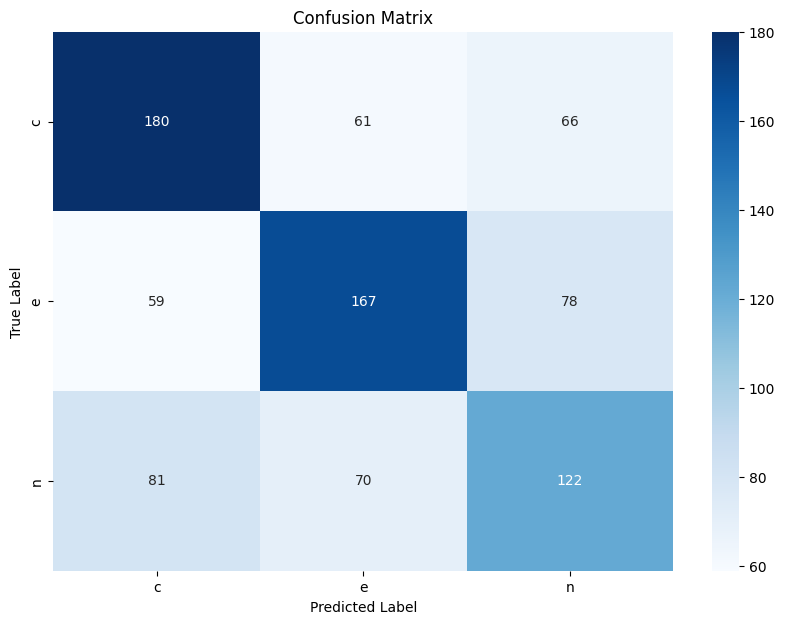

Classification Report:
              precision    recall  f1-score   support

           c       0.56      0.59      0.57       307
           e       0.56      0.55      0.55       304
           n       0.46      0.45      0.45       273

    accuracy                           0.53       884
   macro avg       0.53      0.53      0.53       884
weighted avg       0.53      0.53      0.53       884



In [56]:
labels_mapping = {'c': 0, 'e': 1, 'n': 2}
print(f'MLP Model result for {model_name} on HEB-SNLI')
res = evaluate_model(model=classifier_model, test_x=test_embeddings, y_test=snli_y_test, labels_mapping=labels_mapping)